## **Summary of plots usage** 
- ***Bar Plot:*** Compare frequency, mean, variance, etc. of a variable across groups.
- ***Histogram & KDE:*** Visualize the distribution and shape (skew, modality) of a single variable.
- ***Box Plot:*** Summarize spread, median, and outliers of a variable across groups.
- ***Violin Plot:*** Combine distribution shape and summary stats to compare groups more richly than a box plot.
- ***Scatter Plot:*** Reveal relationships, clusters, or trends between two continuous variables.
- ***Pair Plot:*** Visualize pairwise relationships and distributions across all numeric features simultaneously.
- ***Radar Chart:*** Compare multiple variables or metrics across different models/entities simultaneously on a single chart.
- ***Line Plot:*** Track how a variable changes over time or a continuous sequence.
- ***Correlation Heatmap:*** Spot pairwise linear relationships across all numeric features at a glance.
- ***QQ Plot:*** Check whether a variable follows a theoretical distribution (commonly normality).
- ***t-SNE / UMAP Plot:*** Reduce high-dimensional data to 2D for visualizing clusters and structure.
- ***Multidimensional Scaling Plot:*** Visualize high-dimensional data in 2D/3D by preserving pairwise distances between samples.

In [2]:
import numpy as np
import pandas as pd

In [3]:
from sklearn.datasets import load_iris
iris_bunch = load_iris()

print(type(iris_bunch).__name__)

Bunch


In [4]:
print(iris_bunch.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [5]:
iris_df = pd.DataFrame(data=iris_bunch.data, columns=iris_bunch.feature_names)
iris_df['target'] = iris_bunch.target

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
# rename target values to class names
map = {
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
}

iris_df['target'] = iris_df['target'].map(map)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
# Missing values per column
iris_df.isna().sum(axis=0)

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

$\implies$ No missing data.

## Class-Conditional Histograms

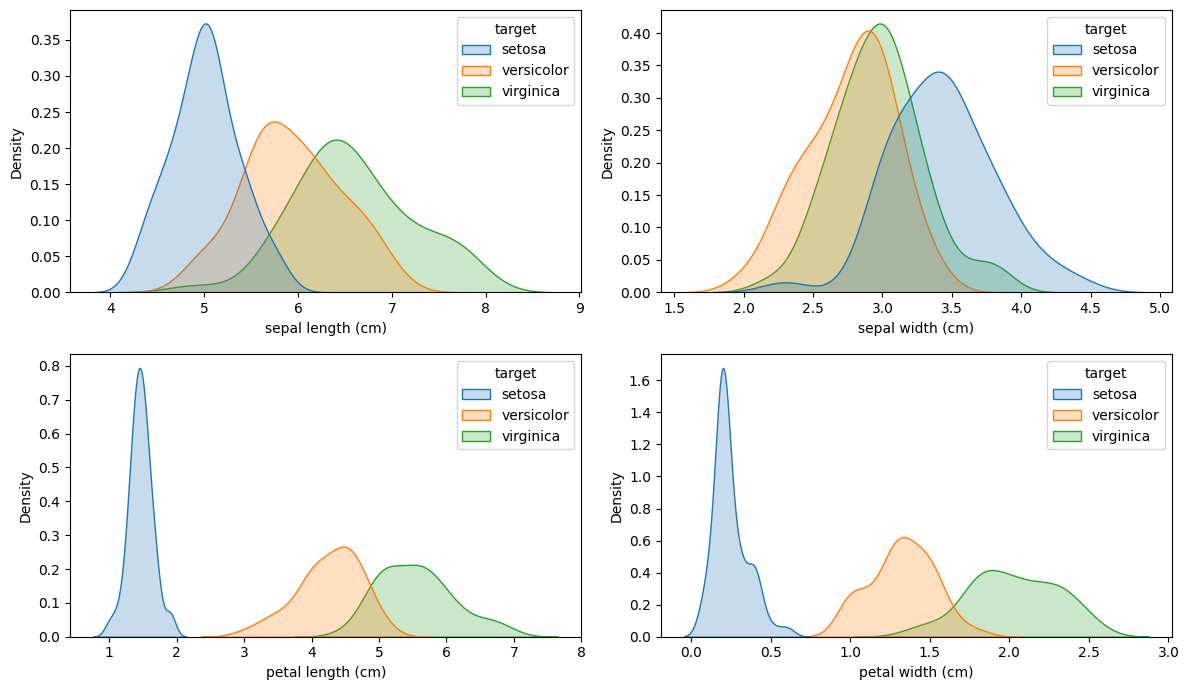

In [8]:
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
for i, col in enumerate(iris_df.columns):
    if col != 'target':
        plt.subplot(2, 2, i+1)
        sns.kdeplot(data=iris_df, x=col, hue='target', fill=True)
plt.tight_layout()
plt.show()

***Histograms - class conditional distribution of features***
1) Petal length and petal width are the most discriminative features because the conditional distributions have peaks that are far apart.
2) Sepal width has heavily overlapping distributions across all three species — it's the least useful feature for classification alone.

## Pair Plot

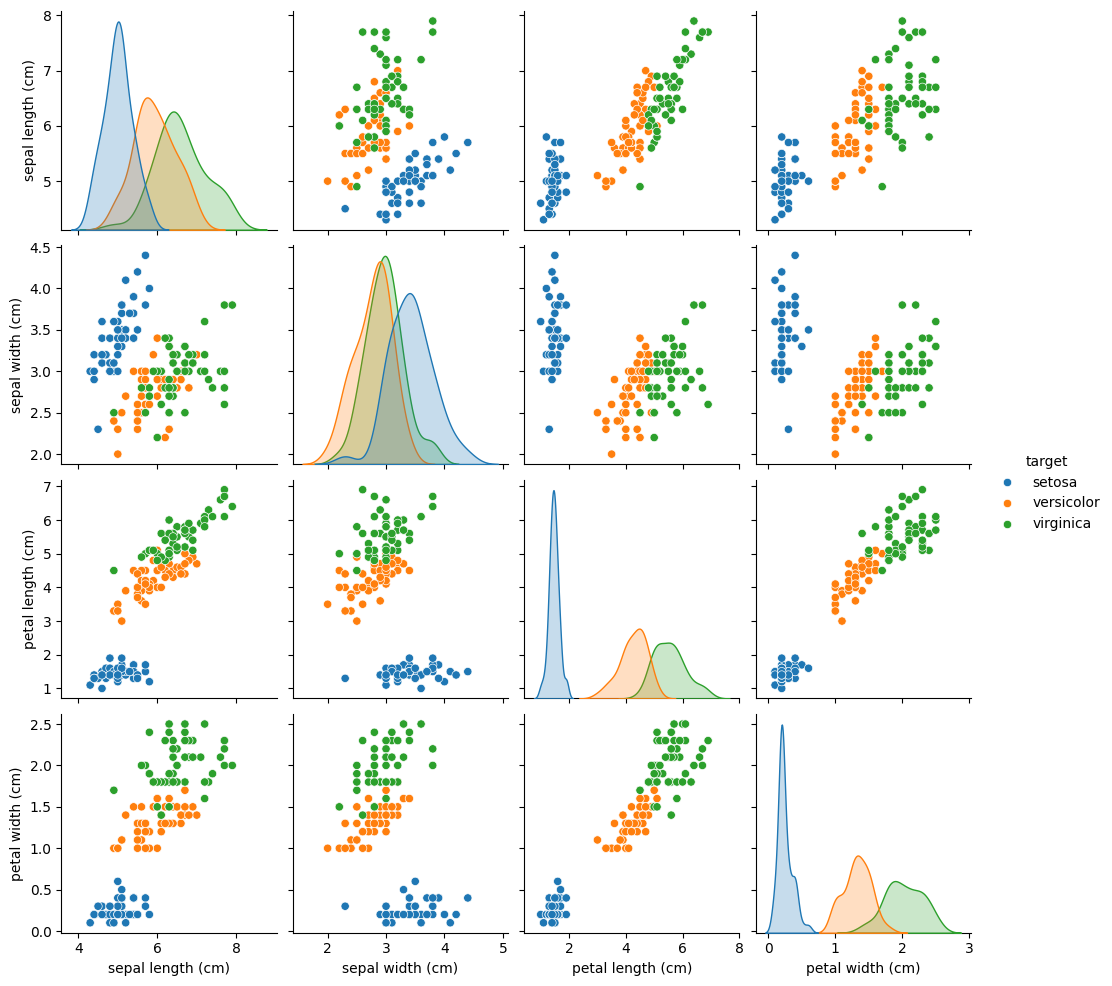

In [9]:
sns.pairplot(iris_df, hue='target')
plt.show()

***Scatter plot - best features for class separation***  
Petal length vs petal width is the clearest visual separator in the dataset. Setosa forms a completely isolated cluster in the bottom-left. Versicolor and Virginica overlap slightly but are still reasonably separable, with Virginica having larger petals overall. A simple linear boundary could classify Setosa with near-perfect accuracy.

## Box Plot

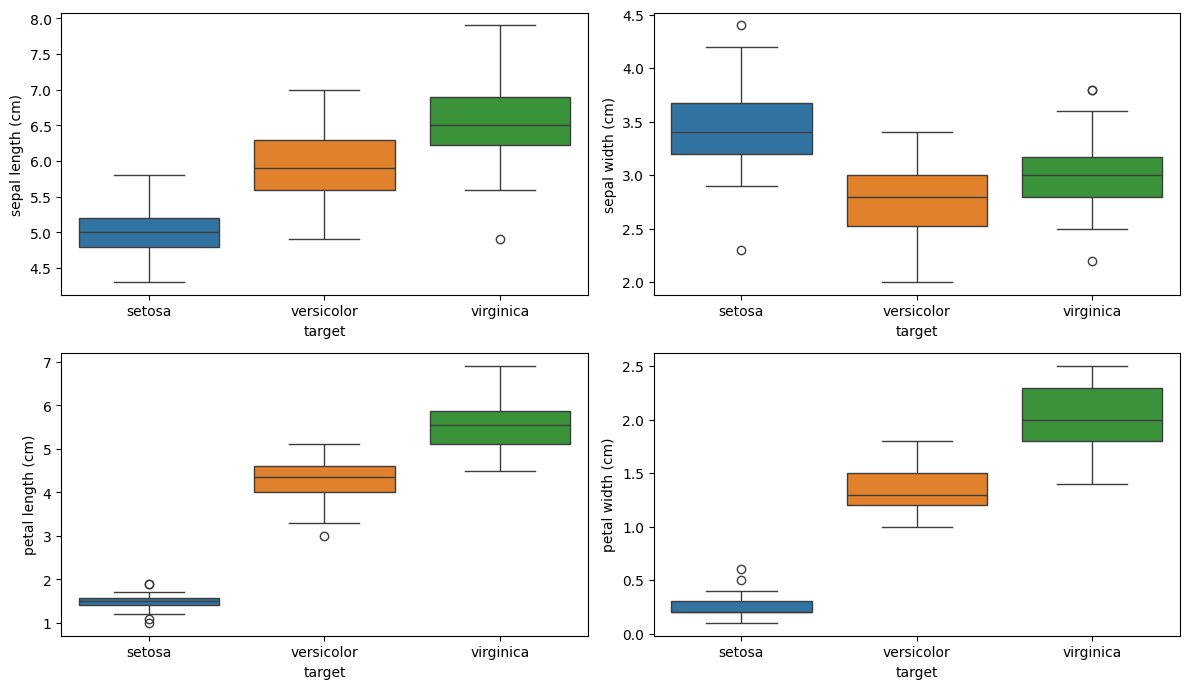

In [10]:
plt.figure(figsize=(12, 7))
for i, col in enumerate(iris_df.columns):
    if col != 'target':
        plt.subplot(2, 2, i+1)
        sns.boxplot(data=iris_df, x='target', y=col, hue='target')
plt.tight_layout()
plt.show()

***Box plot - spread and outliers***  
Setosa has a very narrow spread in petal dimensions (low variance), suggesting it's the most morphologically uniform species. Versicolor sits neatly between the other two in petal length. Virginica has the widest interquartile range on petal features, meaning it's the most variable. Sepal length box plots show more overlap between Versicolor and Virginica.

## Violin Plot

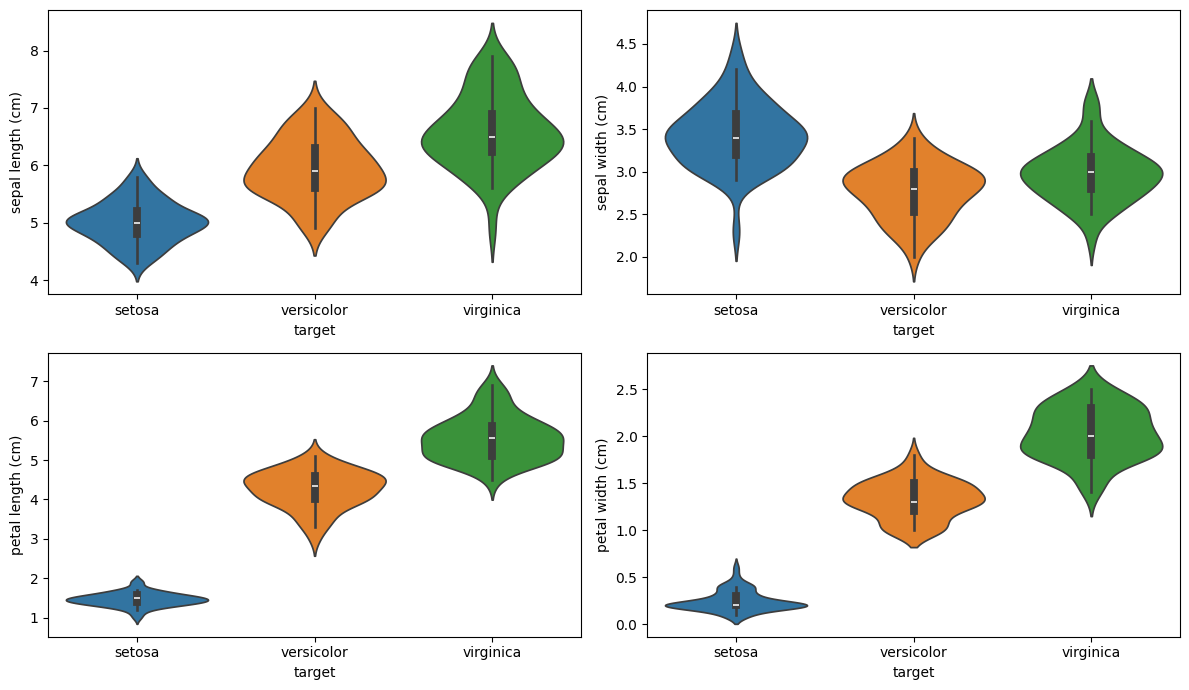

In [11]:
plt.figure(figsize=(12, 7))
for i, col in enumerate(iris_df.columns):
    if col != 'target':
        plt.subplot(2, 2, i+1)
        sns.violinplot(data=iris_df, x='target', y=col, hue='target')
plt.tight_layout()
plt.show()

## Correlation Heatmap

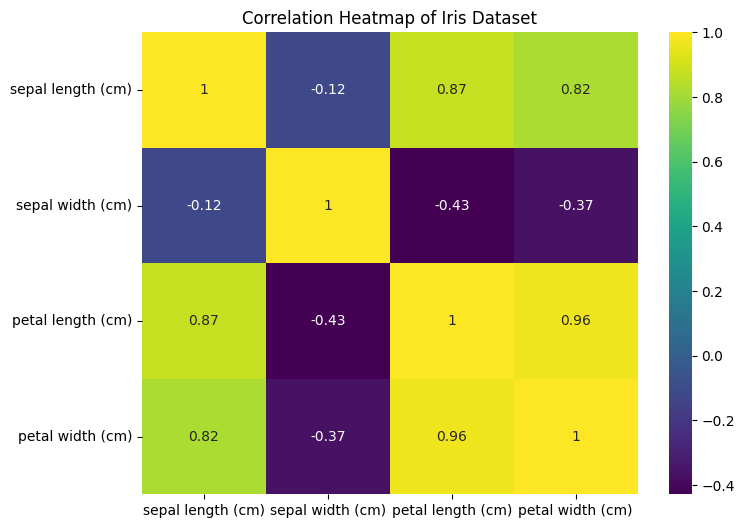

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(iris_df[[col for col in iris_df.columns if col != 'target']].corr(), annot=True, cmap='viridis')
plt.title('Correlation Heatmap of Iris Dataset')
plt.show()

***Correlation heatmap - linearly related features***  
Petal length and petal width are very strongly correlated (r ≈ 0.96) — they grow together proportionally. Sepal length also correlates strongly with petal dimensions (r ≈ 0.80). Sepal width has a weak negative correlation with the other three features, suggesting wider sepals don't accompany larger petals — in fact, Setosa has the widest sepals despite the smallest petals.

## PCA Scatter Plot

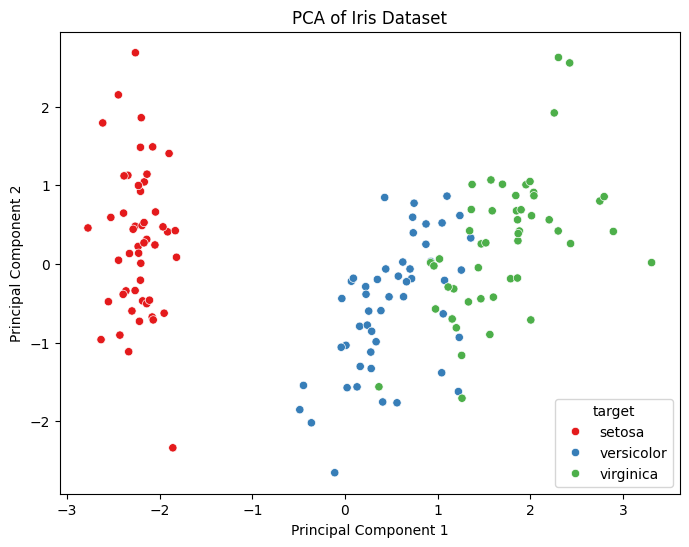

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(iris_df.drop(columns=['target']))

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(data=pca_result, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['target'] = iris_df['target']

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='Principal Component 1', y='Principal Component 2', hue='target', palette='Set1')
plt.title('PCA of Iris Dataset')
plt.show()